In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

In [2]:
df = pd.read_csv("data/customer_purchase_data.csv")
print("Thông tin tổng quan về dữ liệu:")
df.info()

print("Năm dòng đầu tiên:")
display(df.head())

Thông tin tổng quan về dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1500 non-null   int64  
 1   Gender              1500 non-null   int64  
 2   AnnualIncome        1500 non-null   float64
 3   NumberOfPurchases   1500 non-null   int64  
 4   ProductCategory     1500 non-null   int64  
 5   TimeSpentOnWebsite  1500 non-null   float64
 6   LoyaltyProgram      1500 non-null   int64  
 7   DiscountsAvailed    1500 non-null   int64  
 8   PurchaseStatus      1500 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 105.6 KB
Năm dòng đầu tiên:


,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40,1,66120.267939,8,0,30.568601,0,5,1
1,20,1,23579.773583,4,2,38.240097,0,5,0
2,27,1,127821.306432,11,2,31.633212,1,0,1
3,24,1,137798.623120,19,3,46.167059,0,4,1
4,31,1,99300.964220,19,1,19.823592,0,0,1


In [3]:
def custom_train_test_split(dataframe, test_size=0.2, random_state=42):
    if not 0 < test_size < 1:
        raise ValueError("test_size phải nằm trong khoảng (0, 1)")

    rng = np.random.RandomState(random_state)
    shuffled_indices = rng.permutation(len(dataframe))
    test_count = int(round(len(dataframe) * test_size))
    test_indices = shuffled_indices[:test_count]
    train_indices = shuffled_indices[test_count:]

    return (
        dataframe.iloc[train_indices].reset_index(drop=True),
        dataframe.iloc[test_indices].reset_index(drop=True),
    )

df_train, df_test = custom_train_test_split(df, test_size=0.2, random_state=42)
print(f"Số lượng mẫu tập Train: {len(df_train)}")
print(f"Số lượng mẫu tập Test: {len(df_test)}")

Số lượng mẫu tập Train: 1200
Số lượng mẫu tập Test: 300


In [4]:
display(df_train.describe())

purchase_counts = df_train["PurchaseStatus"].value_counts(dropna=False)
purchase_percentages = df_train["PurchaseStatus"].value_counts(normalize=True, dropna=False).mul(100)
purchase_summary = pd.DataFrame({
    "Số lượng": purchase_counts,
    "Tỷ lệ (%)": purchase_percentages.round(2),
})
display(purchase_summary)

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,44.165000,0.501667,84946.585137,10.300000,2.033333,30.573092,0.335000,2.608333,0.433333
std,15.436256,0.500206,37630.558960,5.887746,1.421469,16.959808,0.472187,1.702159,0.495742
min,18.000000,0.000000,20001.512518,0.000000,0.000000,1.037023,0.000000,0.000000,0.000000
25%,31.000000,0.000000,53784.664760,5.000000,1.000000,16.342521,0.000000,1.000000,0.000000
50%,45.000000,1.000000,85211.608196,11.000000,2.000000,30.773367,0.000000,3.000000,0.000000
75%,57.000000,1.000000,117659.549957,15.000000,3.000000,44.373213,1.000000,4.000000,1.000000
max,70.000000,1.000000,149785.176481,20.000000,4.000000,59.991105,1.000000,5.000000,1.000000


,Số lượng,Tỷ lệ (%)
PurchaseStatus,,
0,680,56.67
1,520,43.33


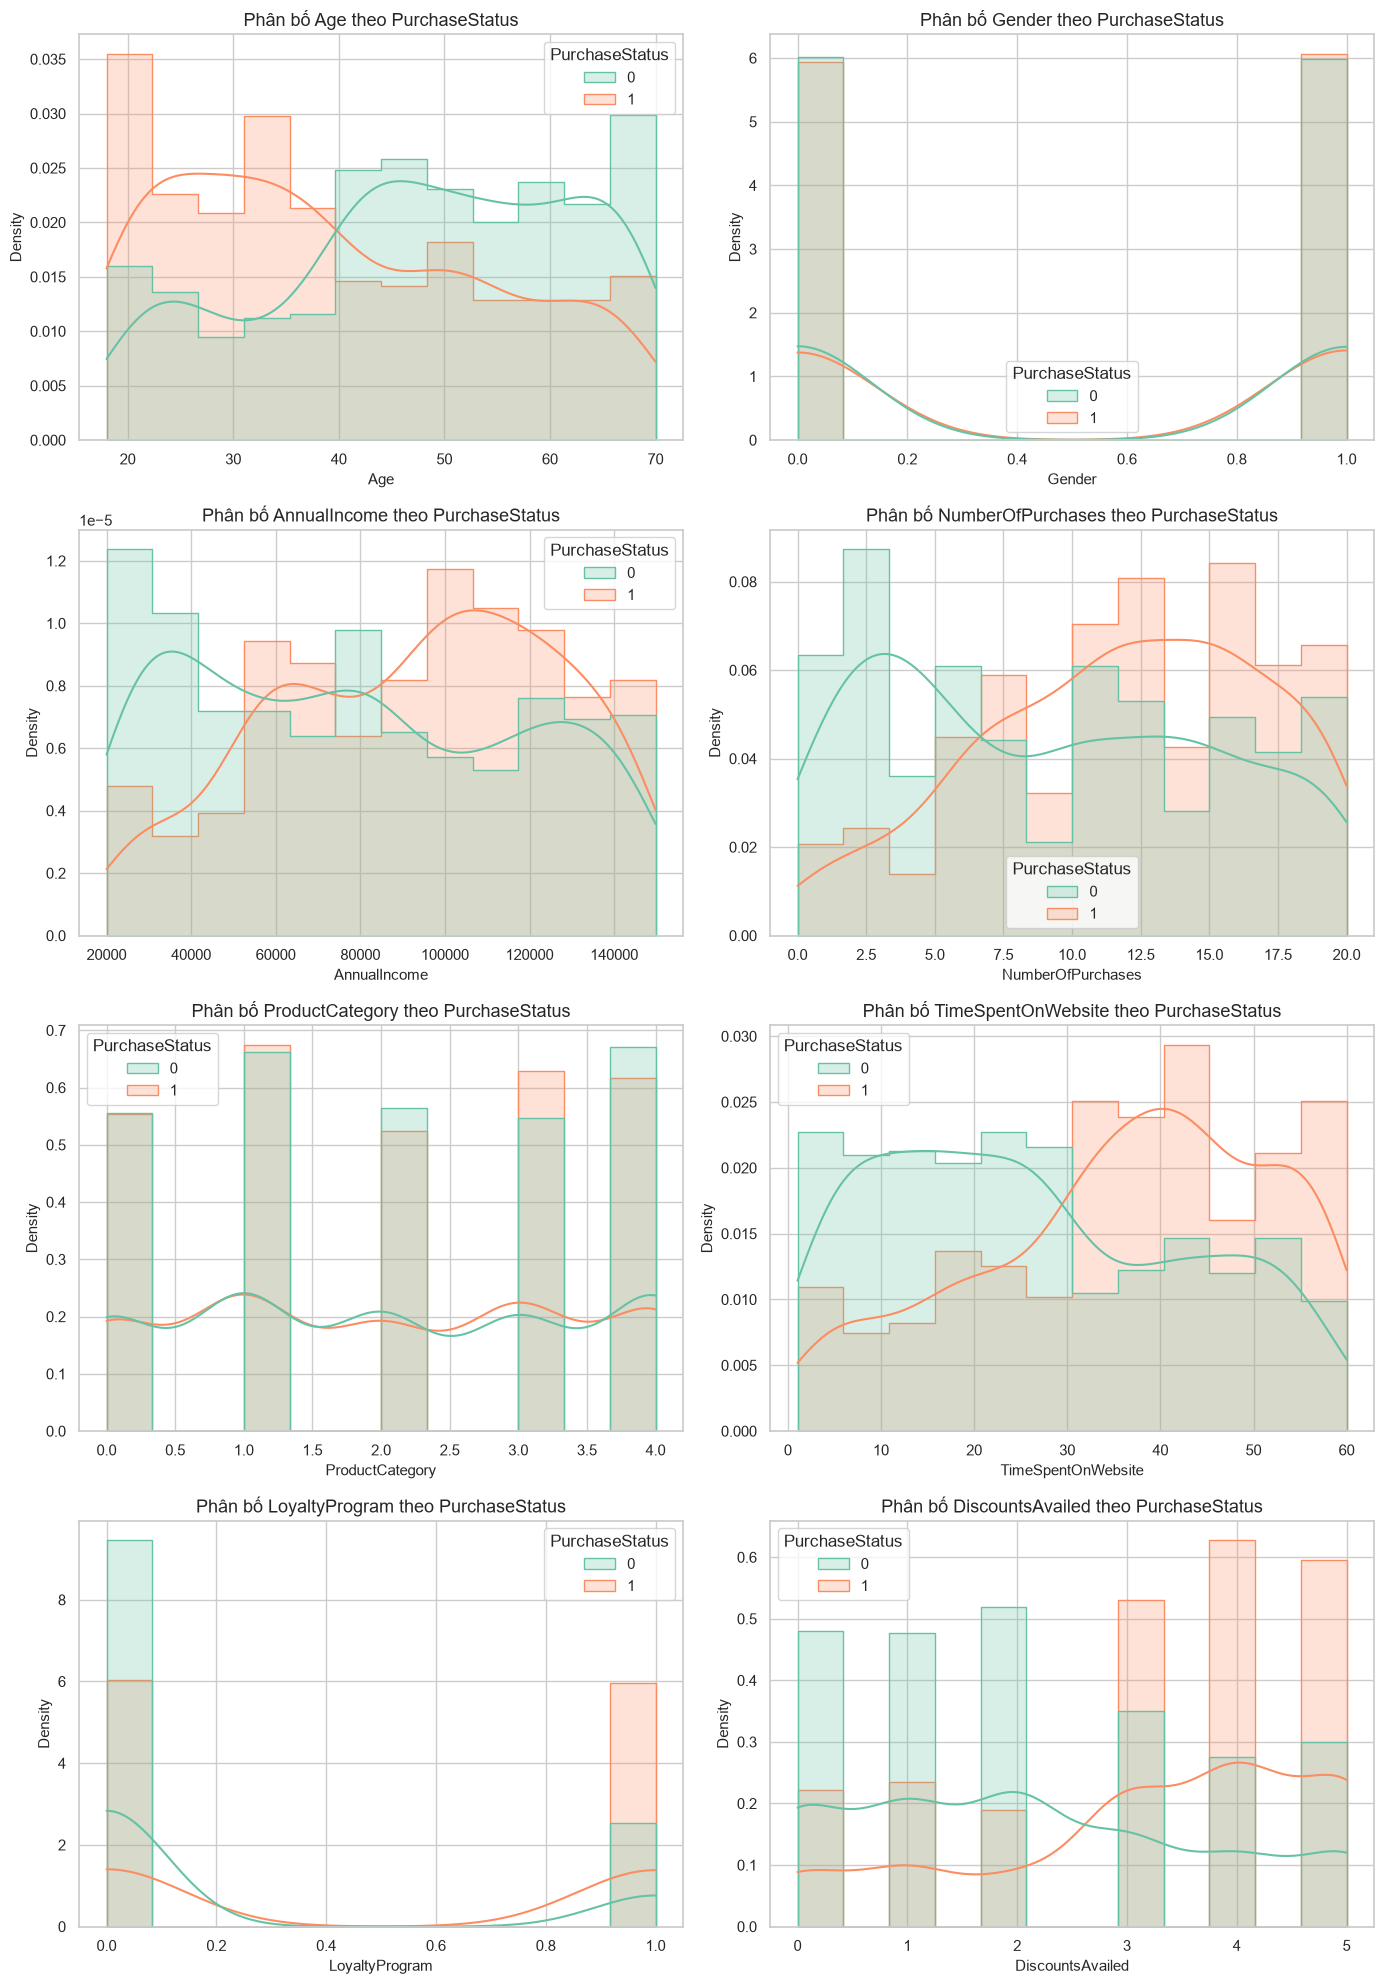

In [5]:
numeric_features = df_train.select_dtypes(include=np.number).columns.tolist()
numeric_features = [feature for feature in numeric_features if feature != "PurchaseStatus"]

columns_per_row = 2
rows = int(np.ceil(len(numeric_features) / columns_per_row))
fig, axes = plt.subplots(rows, columns_per_row, figsize=(14, 5 * rows))
axes = np.atleast_1d(axes).ravel()

for axis, feature in zip(axes, numeric_features):
    sns.histplot(
        data=df_train,
        x=feature,
        hue="PurchaseStatus",
        kde=True,
        element="step",
        stat="density",
        common_norm=False,
        ax=axis,
    )
    axis.set_title(f"Phân bố {feature} theo PurchaseStatus")

for axis in axes[len(numeric_features):]:
    axis.remove()

plt.tight_layout()
plt.show()

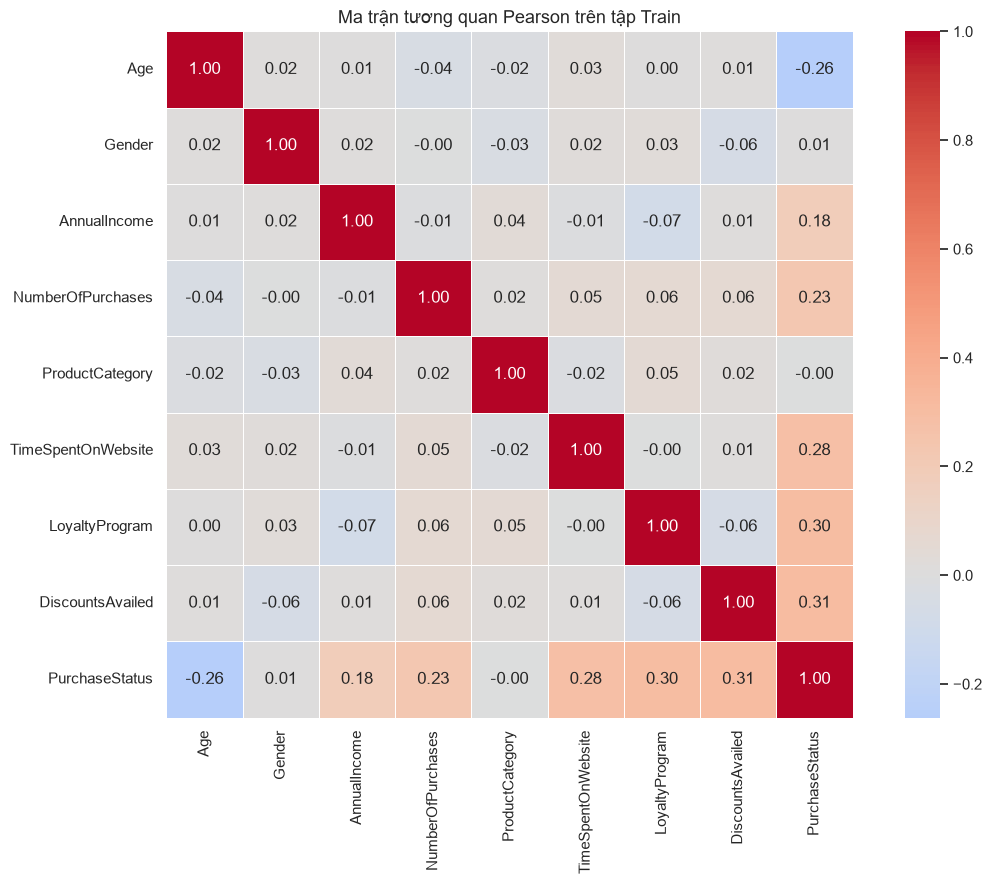

In [6]:
correlation_matrix = df_train.select_dtypes(include=np.number).corr(method="pearson")

plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Ma trận tương quan Pearson trên tập Train")
plt.tight_layout()
plt.show()

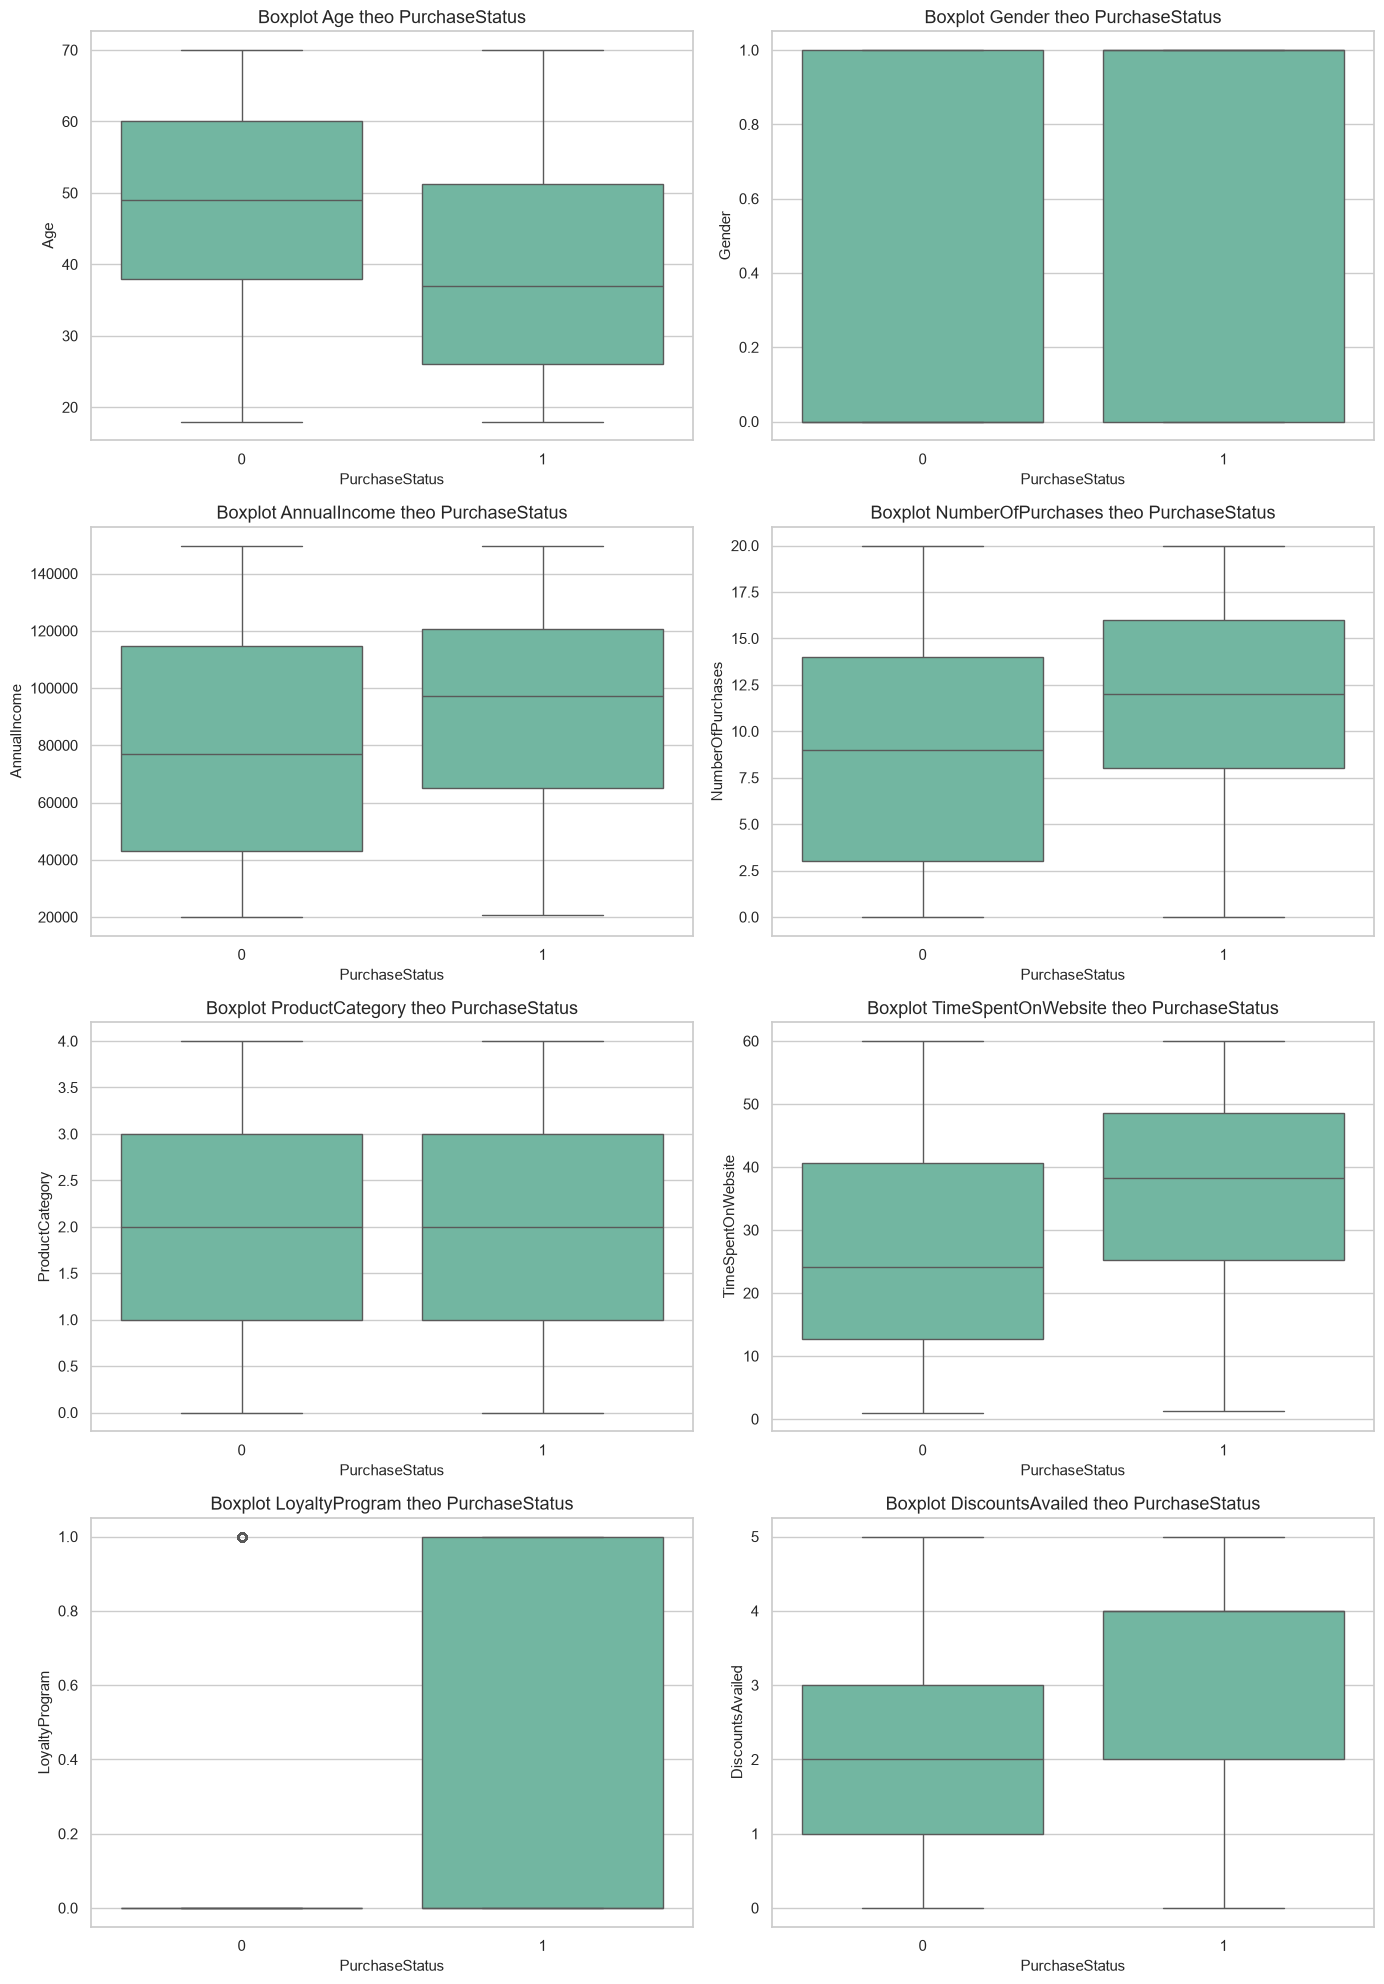

In [7]:
columns_per_row = 2
rows = int(np.ceil(len(numeric_features) / columns_per_row))
fig, axes = plt.subplots(rows, columns_per_row, figsize=(14, 5 * rows))
axes = np.atleast_1d(axes).ravel()

for axis, feature in zip(axes, numeric_features):
    sns.boxplot(data=df_train, x="PurchaseStatus", y=feature, ax=axis)
    axis.set_title(f"Boxplot {feature} theo PurchaseStatus")
    axis.set_xlabel("PurchaseStatus")
    axis.set_ylabel(feature)

for axis in axes[len(numeric_features):]:
    axis.remove()

plt.tight_layout()
plt.show()